# Hail → Solar · M1 → M2 — coupling (does the event hit the asset?)

**Asset:** Hayhurst Texas Solar (EIA 66880) · **Peril:** Hail · **Layer:** M2 (coupling)

M1 gave us a regional **event catalog** (footprints + intensities). M2 asks the asset-specific question:
*for each event, does it hit Hayhurst — and with what probability?* Hail is an **areal hit-or-miss** peril
(A21), so the coupling is a spatial **hit-probability** that thins the regional rate down to the asset.

**This is the step the old repo got wrong** — it used a point spatial factor (≈ `F/A`) that ignores the
asset's own size and *under-counts* the hit probability. We use the correct **Minkowski** form and verify
it against known answers (basics-spot-on). Plan: `docs/plans/hail/phase-3-coupling.md`.

> **The formula.** For an event footprint area `F` and asset footprint area `s` in a region of area `A`:
> **`p = (√F + √s)² / A`**. Per-event (footprint & intensity correlate); `A` **cancels** in
> `λ_asset = λ_collection · p`, so the region size doesn't bias the result (same-region rule, DD-1).

## Assumptions (this layer)

**A11** areal hit-or-miss, Minkowski `(√F+√s)²/A` · **A12** asset footprint `s` ≈ 0.50 km² *(estimate;
`s ≪ F` so insensitive)* · **A13** full exposure on hit · **A14** regional rate `λ_collection` *(**fitted**
~29.6/yr on the ~5.65-yr record — DD-3)*. Full register: [assumptions A11–A14](../../../../docs/plans/hail/assumptions.md#m2--coupling).

In [1]:
from __future__ import annotations
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / ".env").exists() or (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")
ROOT = _repo_root()

ASSET = {"name": "Hayhurst Texas Solar", "eia_plant_id": 66880, "lat": 31.815992, "lon": -104.0853,
         "ac_capacity_mw": 24.8}
RADIUS_MI = 50
EQ_AREA = "EPSG:5070"   # equal-area for any km² we compute here

# --- region area A and asset footprint s ---
R_KM = RADIUS_MI * 1.60934
A_REGION_KM2 = math.pi * R_KM ** 2                       # 50-mi circle ≈ 20,342 km²
ACRES_PER_MW = 5.0                                       # STATED assumption: array (panel) footprint ~5 ac/MW_ac
S_ASSET_KM2 = ASSET["ac_capacity_mw"] * ACRES_PER_MW * 0.00404686   # acres → km²
print(f"region A = {A_REGION_KM2:,.0f} km²  (50-mi circle)")
print(f"asset  s ≈ {S_ASSET_KM2:.3f} km²  ({ASSET['ac_capacity_mw']} MW × {ACRES_PER_MW} ac/MW — STATED estimate)")
print(f"s / mean(F): tiny — coupling is insensitive to s here (s matters more for larger assets / smaller footprints).")

region A = 20,342 km²  (50-mi circle)
asset  s ≈ 0.502 km²  (24.8 MW × 5.0 ac/MW — STATED estimate)
s / mean(F): tiny — coupling is insensitive to s here (s matters more for larger assets / smaller footprints).


## 1 · Load the M1 catalog

Each event carries the `F` (footprint_area_km2) the coupling needs, plus its `peak_intensity_in` (carried
through to M3 damage) and its real polygon `geometry`.

In [2]:
cat = gpd.read_parquet(ROOT / "data/hail/hayhurst_hail_m1_catalog.parquet")
print(f"M1 catalog: {len(cat)} events | F range {cat.footprint_area_km2.min():.0f}–{cat.footprint_area_km2.max():.0f} km²")
cat[["event_id", "footprint_area_km2", "peak_intensity_in", "centroid_lon", "centroid_lat"]].head(12)

M1 catalog: 158 events | F range 1–1913 km²


,event_id,footprint_area_km2,peak_intensity_in,centroid_lon,centroid_lat
0,mrms_hail_20201206,4.2,1.95,-103.9300,31.2100
1,mrms_hail_20210427,1.0,1.35,-103.3950,32.1450
2,mrms_hail_20210515,156.8,2.74,-104.3891,32.1937
3,mrms_hail_20210521,3.1,1.15,-103.9683,32.1483
4,mrms_hail_20210522,43.9,1.65,-104.3464,32.2836
5,mrms_hail_20210523,3.2,1.09,-104.1317,31.3750
6,mrms_hail_20210524,94.5,1.53,-104.2594,31.7844
7,mrms_hail_20210525,95.7,2.08,-104.0780,31.6963
8,mrms_hail_20210526,34.5,1.45,-103.4456,32.1056
9,mrms_hail_20210527,1.0,1.01,-104.2850,32.1050


## 2 · The coupling math (and why the naive form is wrong)

Two convex shapes of area `F` and `s` (disk approximation) **overlap iff their centres are within
`r_F + r_s`** (`r = √(area/π)`). The "hit region" for the event centre is a disk of radius `r_F + r_s`, area
`π(r_F + r_s)² = (√F + √s)²`. Dropped into a region of area `A`, the hit probability is:

**`p = (√F + √s)² / A`.**

- **Old-repo error:** using `F/A` is the **`s → 0`** special case (asset = a dimensionless point). It drops
  the `2√(F·s) + s` terms, so it **under-counts** — by `(1 + √(s/F))²`, which blows up as `F` shrinks.
- **Per-event:** we compute `pᵢ` from each event's own `Fᵢ` (not one constant factor).
- **Rate:** `λ_asset = λ_collection · E[p]`; over the *observed* catalog the expected asset-hits = **`Σ pᵢ`**.
- **`A` cancels:** `λ_collection ∝ A`, `p ∝ 1/A` → `λ_asset` independent of region size (DD-1 same-region rule).

In [3]:
F = cat["footprint_area_km2"].to_numpy()
s = S_ASSET_KM2
p_minkowski = np.minimum((np.sqrt(F) + np.sqrt(s)) ** 2 / A_REGION_KM2, 1.0)   # cap at 1
p_naive     = np.minimum(F / A_REGION_KM2, 1.0)                                # the old-repo point factor
cat = cat.assign(p_hit=p_minkowski, p_naive_FA=p_naive,
                 correction_x=(p_minkowski / p_naive).round(3))
out = cat[["event_id", "footprint_area_km2", "p_hit", "p_naive_FA", "correction_x", "peak_intensity_in"]] \
        .sort_values("p_hit", ascending=False)
print(f"per-event hit probability pᵢ (Minkowski). Σpᵢ = {p_minkowski.sum():.3f} expected asset-hits over the catalog.")
out

per-event hit probability pᵢ (Minkowski). Σpᵢ = 1.394 expected asset-hits over the catalog.


,event_id,footprint_area_km2,p_hit,p_naive_FA,correction_x,peak_intensity_in
11,mrms_hail_20210529,1913.2,0.097125,0.094053,1.033,2.62
120,mrms_hail_20250610,1883.5,0.095641,0.092593,1.033,3.21
112,mrms_hail_20250506,1787.2,0.090828,0.087859,1.034,3.02
36,mrms_hail_20220601,1430.2,0.072968,0.070309,1.038,4.51
108,mrms_hail_20250426,1305.3,0.066710,0.064169,1.040,3.93
...,...,...,...,...,...,...
133,mrms_hail_20250703,1.0,0.000143,0.000049,2.919,1.03
142,mrms_hail_20250908,1.0,0.000143,0.000049,2.919,1.04
12,mrms_hail_20210530,1.0,0.000143,0.000049,2.919,1.02
9,mrms_hail_20210527,1.0,0.000143,0.000049,2.919,1.01


## 3 · Known-answer check — confirm the formula before trusting it  *(basics-spot-on)*

A basic isn't "done" until hand-computable cases confirm it.

In [4]:
def p_hit(F, s, A): return (math.sqrt(F) + math.sqrt(s)) ** 2 / A
checks = [
    ("s → 0 recovers the naive F/A",         abs(p_hit(400, 0, A_REGION_KM2) - 400 / A_REGION_KM2) < 1e-12),
    ("equal disks F=s → hit area = 4F",      abs(p_hit(10, 10, A_REGION_KM2) - 4 * 10 / A_REGION_KM2) < 1e-12),
    ("event fills region (F=A,s→0) → p=1",   abs(p_hit(A_REGION_KM2, 0, A_REGION_KM2) - 1.0) < 1e-12),
    ("monotone in F (bigger footprint hits more)", p_hit(800, s, A_REGION_KM2) > p_hit(80, s, A_REGION_KM2)),
    ("Minkowski ≥ naive always",             all((np.sqrt(F) + np.sqrt(s)) ** 2 >= F)),
]
for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
assert all(ok for _, ok in checks), "a known-answer check failed — do not trust the coupling"
print("\nall known-answer checks pass ✓")

  [PASS]  s → 0 recovers the naive F/A
  [PASS]  equal disks F=s → hit area = 4F
  [PASS]  event fills region (F=A,s→0) → p=1
  [PASS]  monotone in F (bigger footprint hits more)
  [PASS]  Minkowski ≥ naive always

all known-answer checks pass ✓


## 4 · The old-repo error, quantified

How badly does the naive `F/A` under-count? The correction `(1+√(s/F))²` is small for big footprints and
large for small ones — exactly where the asset's own size stops being negligible.

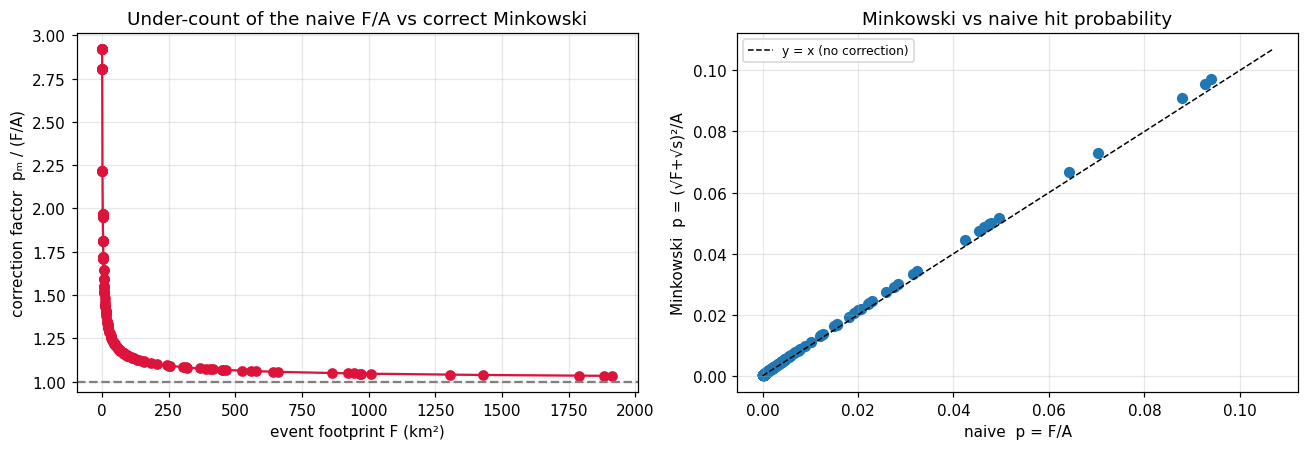

correction ranges 1.03× (biggest footprint) … 2.92× (smallest).
→ the old repo's point factor under-counts most for SMALL events. For larger assets / smaller footprints / other
  perils the gap is far bigger (the documented 1.3–7×) — which is why the Minkowski form is non-negotiable.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
order = np.argsort(F)
ax[0].plot(F[order], (p_minkowski / p_naive)[order], "o-", color="crimson")
ax[0].set(title="Under-count of the naive F/A vs correct Minkowski", xlabel="event footprint F (km²)",
          ylabel="correction factor  pₘ / (F/A)"); ax[0].axhline(1, color="gray", ls="--")
ax[1].scatter(p_naive, p_minkowski, s=40)
lim = max(p_minkowski.max(), p_naive.max()) * 1.1
ax[1].plot([0, lim], [0, lim], "k--", lw=1, label="y = x (no correction)")
ax[1].set(title="Minkowski vs naive hit probability", xlabel="naive  p = F/A", ylabel="Minkowski  p = (√F+√s)²/A")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"correction ranges {(p_minkowski/p_naive).min():.2f}× (biggest footprint) … {(p_minkowski/p_naive).max():.2f}× (smallest).")
print("→ the old repo's point factor under-counts most for SMALL events. For larger assets / smaller footprints / other")
print("  perils the gap is far bigger (the documented 1.3–7×) — which is why the Minkowski form is non-negotiable.")

## 5 · Expected asset-hits → **λ_asset** (now *fitted* — DD-3 Stage 1)

`Σ pᵢ` is the expected asset-hits over the *catalog*. With the widened record, `λ_collection` is now
**fitted** in M1 (~29.6/yr), so we can finally annualize: **`λ_asset = λ_collection · mean(pᵢ)`** — the
asset's real (if record-limited) annual hit rate, which M4's Monte Carlo consumes.

In [6]:
sum_p = float(p_minkowski.sum())
man = json.load(open(ROOT / "data/hail/hayhurst_hail_m1_manifest.json"))
lam_collection = man["frequency_process_params"]["lambda_collection_per_yr"]    # FITTED in M1 (DD-3 Stage 1)
mean_p = float(p_minkowski.mean())
lam_asset = lam_collection * mean_p
print(f"expected asset-hits over the catalog  Σpᵢ = {sum_p:.3f}  (naive ΣF/A = {p_naive.sum():.3f}, {sum_p/p_naive.sum():.2f}× lower)")
print(f"λ_collection (fitted, M1) = {lam_collection}/yr · mean pᵢ = {mean_p:.4f}")
print(f"→ λ_asset = λ_collection × mean(pᵢ) = {lam_asset:.3f} hits/yr  (≈ 1 every {1/lam_asset:.1f} yr) — the real (record-limited) rate M4 uses")

expected asset-hits over the catalog  Σpᵢ = 1.394  (naive ΣF/A = 1.293, 1.08× lower)
λ_collection (fitted, M1) = 29.6/yr · mean pᵢ = 0.0088
→ λ_asset = λ_collection × mean(pᵢ) = 0.261 hits/yr  (≈ 1 every 3.8 yr) — the real (record-limited) rate M4 uses


## 6 · Cross-check — did any event *actually* cover the asset?  (geometric overlap)

The `pᵢ` are *expectations* over random placement. Because we have the real footprints at known locations,
we can also ask the deterministic question: did any event polygon actually contain the asset point? Even over
the ~5.6-yr record this is **noisy** (it ignores the asset's size; a single point rarely sits under a swath)
— which is exactly why the Minkowski *expectation* (`Σpᵢ`), not the raw point-hit count, is the stable
estimator that converges as the region/record grow.

In [7]:
asset_pt = Point(ASSET["lon"], ASSET["lat"])
cat["hit_geometric"] = cat.geometry.contains(asset_pt) | cat.geometry.intersects(asset_pt)
n_geo = int(cat["hit_geometric"].sum())
print(f"events whose footprint actually contains the asset POINT: {n_geo}")
print(f"vs expected point-hits Σ(F/A) = {p_naive.sum():.3f}  and Minkowski Σpᵢ = {sum_p:.3f}")
print("→ empirical point-hits are a tiny, noisy integer; the Minkowski expectation is the smooth estimate to carry forward.")

events whose footprint actually contains the asset POINT: 1
vs expected point-hits Σ(F/A) = 1.293  and Minkowski Σpᵢ = 1.394
→ empirical point-hits are a tiny, noisy integer; the Minkowski expectation is the smooth estimate to carry forward.


**Map — the coupling, visually.** Event footprints shaded by hit probability `pᵢ`; bigger/closer-to-filling
footprints are likelier to hit. The asset sits at the centre; the 50-mi region is the area `A` that cancels.

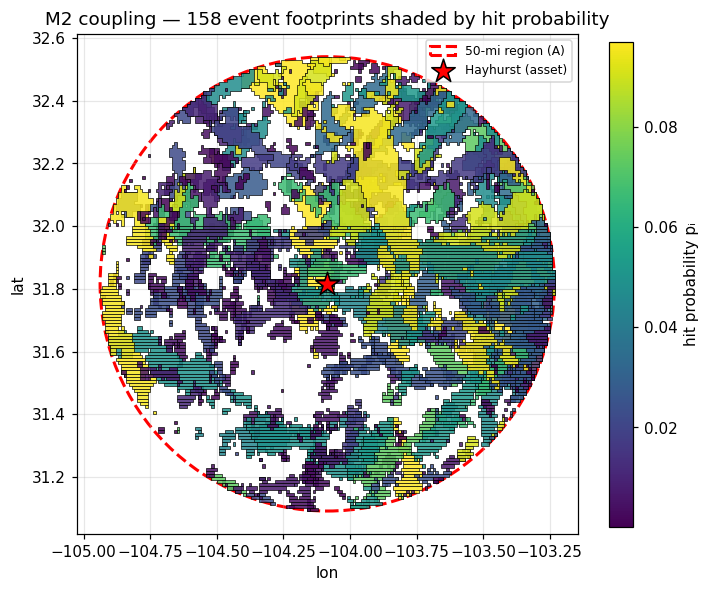

In [8]:
dlat = RADIUS_MI / 69.0; dlon = RADIUS_MI / (69.0 * math.cos(math.radians(ASSET["lat"])))
fig, ax = plt.subplots(figsize=(6.6, 6.6))
cat.plot(ax=ax, column="p_hit", cmap="viridis", edgecolor="k", linewidth=0.5, alpha=0.85,
         legend=True, legend_kwds={"label": "hit probability pᵢ", "shrink": 0.7}, zorder=4)
ax.add_patch(Ellipse((ASSET["lon"], ASSET["lat"]), 2*dlon, 2*dlat, fill=False, ec="red", ls="--", lw=2, label="50-mi region (A)"))
ax.scatter([ASSET["lon"]], [ASSET["lat"]], marker="*", s=260, color="red", ec="black", zorder=6, label="Hayhurst (asset)")
ax.set(title=f"M2 coupling — {len(cat)} event footprints shaded by hit probability", xlabel="lon", ylabel="lat")
ax.legend(loc="upper right", fontsize=8); ax.set_aspect(1/math.cos(math.radians(ASSET["lat"])))
plt.tight_layout(); plt.show()

## 7 · Persist the asset-coupled event set → `data/hail/`

The M2 artifact: each event with its hit probability `pᵢ` and its `peak_intensity_in` — the exact inputs M3
(damage) consumes — plus a small summary (region, asset, Σpᵢ, the stated assumptions, the fitted rate).

In [9]:
m2_cols = ["event_id", "catalog_id", "footprint_area_km2", "p_hit", "p_naive_FA", "correction_x",
           "hit_geometric", "peak_intensity_in", "peak_intensity_mm", "valid_time_utc", "geometry"]
m2 = cat[m2_cols].copy()
out_dir = ROOT / "data" / "hail"
m2.to_parquet(out_dir / "hayhurst_hail_m2_coupled.parquet")
summary = {
    "layer": "M2_coupling", "peril": "HAIL", "asset": ASSET["name"], "catalog_id": str(cat["catalog_id"].iloc[0]),
    "coupling_type": "areal_hit_or_miss (Minkowski)", "formula": "p = (sqrt(F)+sqrt(s))**2 / A",
    "region_area_km2": round(A_REGION_KM2, 1), "asset_footprint_km2": round(S_ASSET_KM2, 4),
    "asset_footprint_assumption": f"{ASSET['ac_capacity_mw']} MW x {ACRES_PER_MW} acres/MW (array footprint estimate)",
    "expected_hits_over_catalog_sum_p": round(sum_p, 4),
    "lambda_collection_per_yr": lam_collection, "mean_p_hit": round(mean_p, 4),
    "lambda_asset_per_yr": round(lam_asset, 4),
    "lambda_asset_status": "fitted (DD-3 Stage 1) — λ_collection from the ~5.65-yr MRMS record; record-limited",
    "geometric_point_hits": n_geo,
    "provenance": {"plan": "docs/plans/hail/phase-3-coupling.md", "from": "hayhurst_hail_m1_catalog.parquet"},
}
(out_dir / "hayhurst_hail_m2_summary.json").write_text(json.dumps(summary, indent=2))
print(f"M2 coupled events: {len(m2)} → {out_dir/'hayhurst_hail_m2_coupled.parquet'}")
print(f"M2 summary:                → {out_dir/'hayhurst_hail_m2_summary.json'}")
m2.drop(columns="geometry").head()

M2 coupled events: 158 → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m2_coupled.parquet
M2 summary:                → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m2_summary.json


,event_id,catalog_id,footprint_area_km2,p_hit,p_naive_FA,correction_x,hit_geometric,peak_intensity_in,peak_intensity_mm,valid_time_utc
0,mrms_hail_20201206,hail_hayhurst_50mi_v1,4.2,0.000374,0.000206,1.811,False,1.95,49.6,2020-12-06 23:30:00+00:00
1,mrms_hail_20210427,hail_hayhurst_50mi_v1,1.0,0.000143,0.000049,2.919,False,1.35,34.4,2021-04-27 23:30:00+00:00
2,mrms_hail_20210515,hail_hayhurst_50mi_v1,156.8,0.008605,0.007708,1.116,False,2.74,69.5,2021-05-15 23:30:00+00:00
3,mrms_hail_20210521,hail_hayhurst_50mi_v1,3.1,0.000300,0.000152,1.967,False,1.15,29.2,2021-05-21 23:30:00+00:00
4,mrms_hail_20210522,hail_hayhurst_50mi_v1,43.9,0.002644,0.002158,1.225,False,1.65,41.8,2021-05-22 23:30:00+00:00


## Findings & carried-forward

- **The spatial coupling is done — and done right.** Per-event Minkowski hit probability `pᵢ = (√F+√s)²/A`,
  verified against known answers. It **fixes the old repo's point-factor error** (`F/A`), which under-counts
  by ~1.03× (biggest footprint) up to ~2.9× (smallest) here — and far more for larger assets / other perils.
- **Expected asset-hits over the ~5.6-yr catalog: `Σpᵢ ≈ 1.4`** (158 events). And `λ_asset` is now
  **fitted** ≈ 0.26/yr (`λ_collection` from M1, DD-3) — *no longer deferred*. `A` cancels, so the region
  choice doesn't bias it.
- **`s ≪ F` for hail**, so the result is insensitive to the asset-footprint estimate here; `s` (and the
  actual plant polygon) matter more for larger assets / smaller footprints / other perils.
- **Next — M3 (damage):** map each coupled event's `peak_intensity_in` through a **PV hail-fragility curve**
  → event damage, then assemble `pᵢ` + `λ_asset` in the **compound-Poisson Monte Carlo** for EAL / VaR / PML
  (A22; `hazard_math/02–05`; the part the old repo broke — done right + verified).